# 01b — InHARD Exploratory Analysis

Charts for the **full external dataset** (auto-detected via `lib.paths.find_inhard_root()`).

**Saved artifacts (commit to repo):** `outputs/inhard_eda/`  
→ `REPORT.md`, `inhard_eda_summary.json`, PNGs, CSVs

| Chart | Question |
|-------|----------|
| Class balance | How many clips per meta-action? |
| Duration | How long are clips (seconds)? |
| Sessions | Which `P##_R##` recordings contribute most? |
| Subjects / operations | Who and which assembly ops? |

**Pipeline policy:** `Assemble system` + `No action` = **blocked** (grey bars).  
**12 trainable** actions = green bars.

In [1]:
import sys
from pathlib import Path

NB = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from lib.constants import BLOCKED_ACTIONS, TRAINABLE_ACTIONS
from lib.inhard_eda import load_segmented_eda, disk_vs_csv_summary, save_eda_summary
from lib.paths import OUTPUTS_DIR, find_inhard_root, set_inhard_root

# Uncomment to force external HD:
# set_inhard_root("/Volumes/Carlos Pano HD/MASTER-AI/PROYECTO INTEGRADOR/IN-HARD/01-InHARD")

ROOT = find_inhard_root()
OUT = OUTPUTS_DIR / "inhard_eda"
OUT.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

print("InHARD root:", ROOT)
if ROOT is None:
    raise FileNotFoundError("Mount external drive or set_inhard_root(...)")

InHARD root: /Volumes/Carlos Pano HD/MASTER-AI/PROYECTO INTEGRADOR/IN-HARD/01-InHARD


In [2]:
df = load_segmented_eda(ROOT)
summary = disk_vs_csv_summary(ROOT)

print(f"CSV rows: {len(df):,}")
print(f"Disk mp4:  {summary['disk_mp4_total']:,}  (match={summary['csv_matches_disk']})")
print(f"Trainable: {summary['trainable_clips_disk']:,} clips / {summary['trainable_classes']} classes")
print(f"Blocked:   {summary['blocked_clips_disk']:,} clips")
print(f"Sessions:  {df['session'].nunique()}  Subjects: {df['Subject'].nunique()}  Ops: {df['Operation'].nunique()}")

display(df.groupby("is_trainable")["meta_action"].count().rename("clips").to_frame())
save_eda_summary(df, ROOT)

CSV rows: 5,303
Disk mp4:  5,303  (match=True)
Trainable: 3,425 clips / 12 classes
Blocked:   1,878 clips
Sessions:  38  Subjects: 16  Ops: 8


,clips
is_trainable,
False,1878
True,3425


PosixPath('/Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/notebooks/outputs/inhard_eda_summary.json')

## 1 — Class balance (all 14 meta-actions)

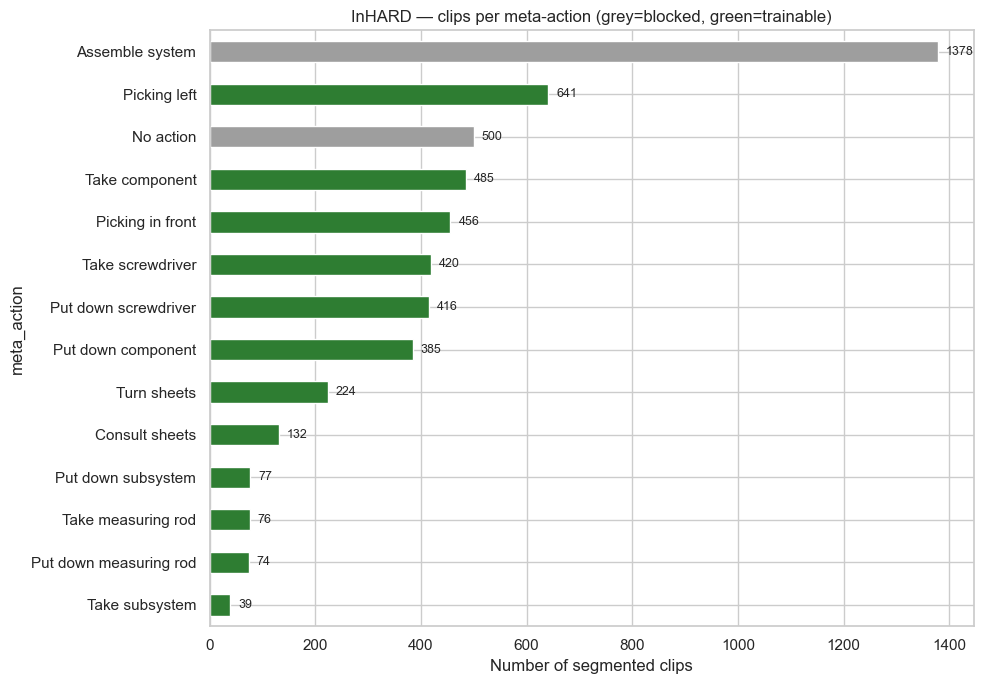

In [3]:
counts = df["meta_action"].value_counts().sort_values(ascending=True)
colors = ["#9e9e9e" if lbl in BLOCKED_ACTIONS else "#2e7d32" for lbl in counts.index]

fig, ax = plt.subplots(figsize=(10, 7))
counts.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Number of segmented clips")
ax.set_title("InHARD — clips per meta-action (grey=blocked, green=trainable)")
for i, (lbl, n) in enumerate(counts.items()):
    ax.text(n + 15, i, str(n), va="center", fontsize=9)
plt.tight_layout()
fig.savefig(OUT / "01_class_balance_all.png", dpi=140)
plt.show()

## 2 — Trainable classes only (12 actions for our HAR pipeline)

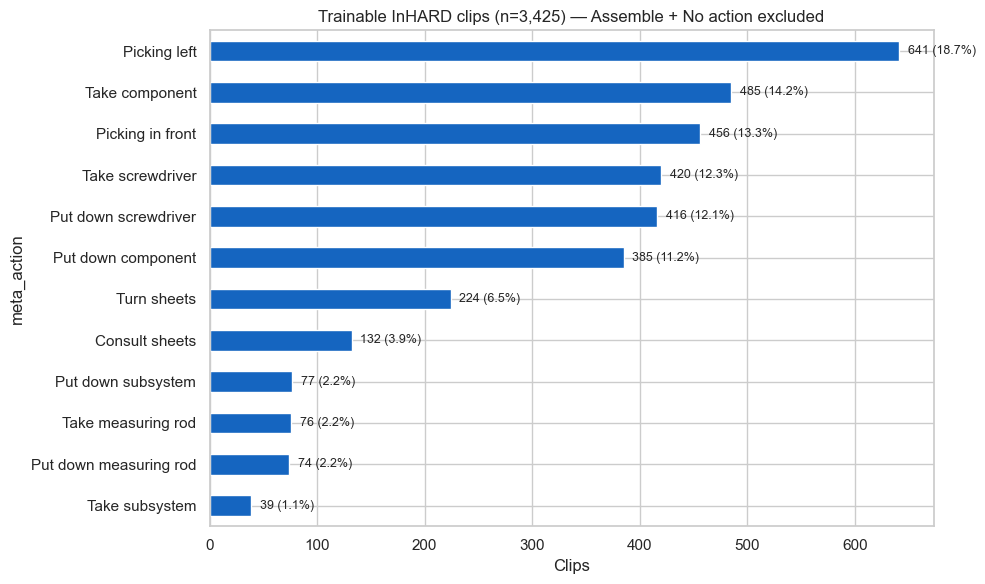

In [4]:
train = df[df["is_trainable"]].copy()
tc = train["meta_action"].value_counts().sort_values(ascending=True)
pct = (tc / tc.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
tc.plot(kind="barh", ax=ax, color="#1565c0")
ax.set_xlabel("Clips")
ax.set_title(f"Trainable InHARD clips (n={len(train):,}) — Assemble + No action excluded")
for i, (lbl, n) in enumerate(tc.items()):
    ax.text(n + 8, i, f"{n} ({pct[lbl]}%)", va="center", fontsize=9)
plt.tight_layout()
fig.savefig(OUT / "02_class_balance_trainable.png", dpi=140)
plt.show()

## 3 — Duration distribution (seconds)

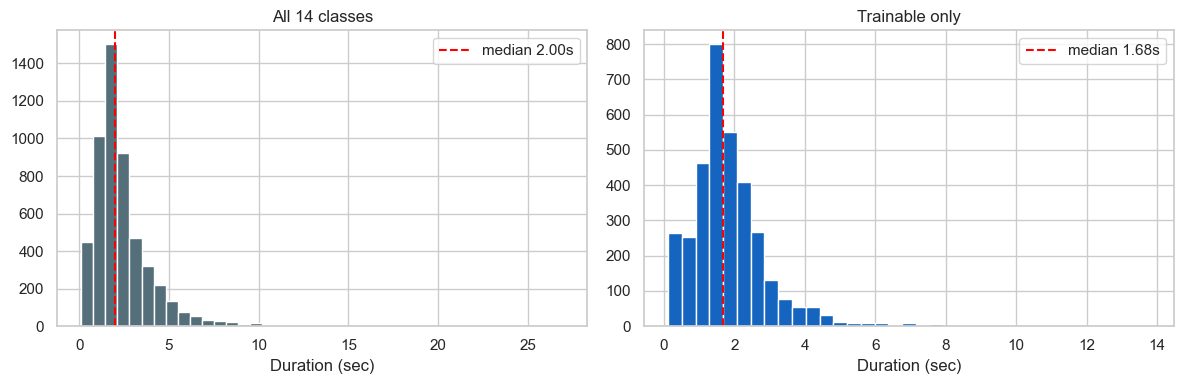

count    3425.00
mean        1.85
std         1.15
min         0.12
25%         1.20
50%         1.68
75%         2.28
max        13.80
Name: Duration_sec, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Duration_sec"], bins=40, color="#546e7a", edgecolor="white")
axes[0].set_title("All 14 classes")
axes[0].set_xlabel("Duration (sec)")
axes[0].axvline(df["Duration_sec"].median(), color="red", ls="--", label=f"median {df['Duration_sec'].median():.2f}s")
axes[0].legend()

axes[1].hist(train["Duration_sec"], bins=35, color="#1565c0", edgecolor="white")
axes[1].set_title("Trainable only")
axes[1].set_xlabel("Duration (sec)")
axes[1].axvline(train["Duration_sec"].median(), color="red", ls="--", label=f"median {train['Duration_sec'].median():.2f}s")
axes[1].legend()

plt.tight_layout()
fig.savefig(OUT / "03_duration_histogram.png", dpi=140)
plt.show()

print(train["Duration_sec"].describe().round(2))

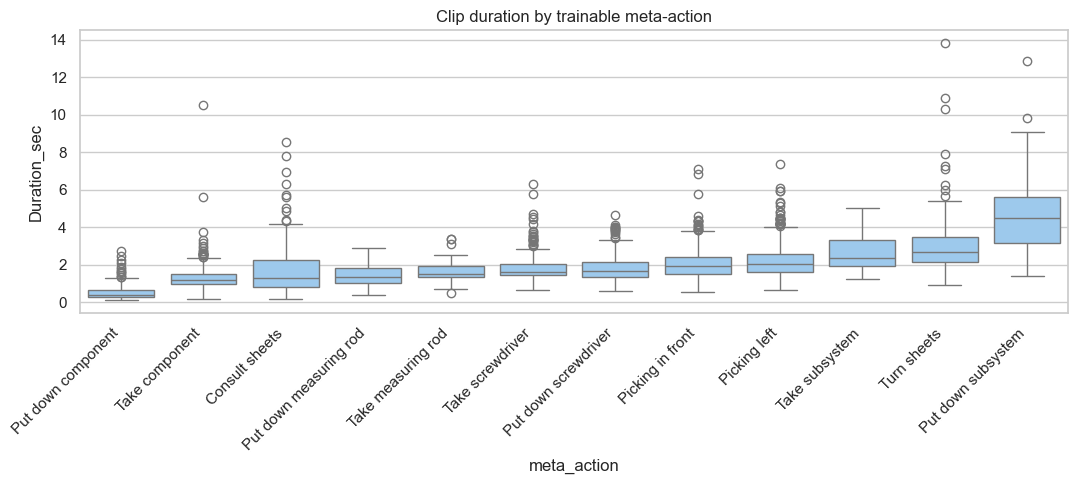

In [6]:
order = train.groupby("meta_action")["Duration_sec"].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=train, x="meta_action", y="Duration_sec", order=order, ax=ax, color="#90caf9")
plt.xticks(rotation=45, ha="right")
ax.set_title("Clip duration by trainable meta-action")
plt.tight_layout()
fig.savefig(OUT / "04_duration_by_class.png", dpi=140)
plt.show()

## 4 — Session breakdown (`File` = P##_R##)

,clips,trainable,subject
session,,,
P06_R01,198,132,P06
P04_R01,173,110,P04
P08_R02,168,119,P08
P04_R02,168,115,P04
P05_R01,165,104,P05
P08_R01,163,112,P08
P05_R02,163,107,P05
P07_R02,155,105,P07
P12_R01,153,96,P12


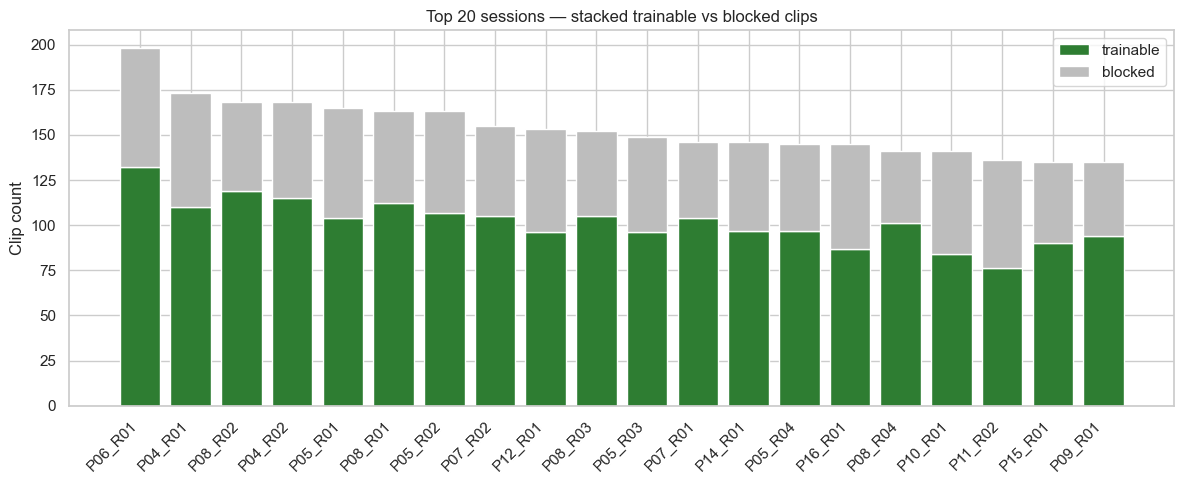

In [7]:
sess = df.groupby("session").agg(
    clips=("meta_action", "count"),
    trainable=("is_trainable", "sum"),
    subject=("Subject", "first"),
).sort_values("clips", ascending=False)

display(sess.head(15))

fig, ax = plt.subplots(figsize=(12, 5))
top = sess.head(20)
x = range(len(top))
ax.bar(x, top["trainable"], label="trainable", color="#2e7d32")
ax.bar(x, top["clips"] - top["trainable"], bottom=top["trainable"], label="blocked", color="#bdbdbd")
ax.set_xticks(list(x))
ax.set_xticklabels(top.index, rotation=45, ha="right")
ax.set_ylabel("Clip count")
ax.set_title("Top 20 sessions — stacked trainable vs blocked clips")
ax.legend()
plt.tight_layout()
fig.savefig(OUT / "05_session_breakdown.png", dpi=140)
plt.show()

## 5 — Subject × operation heatmap

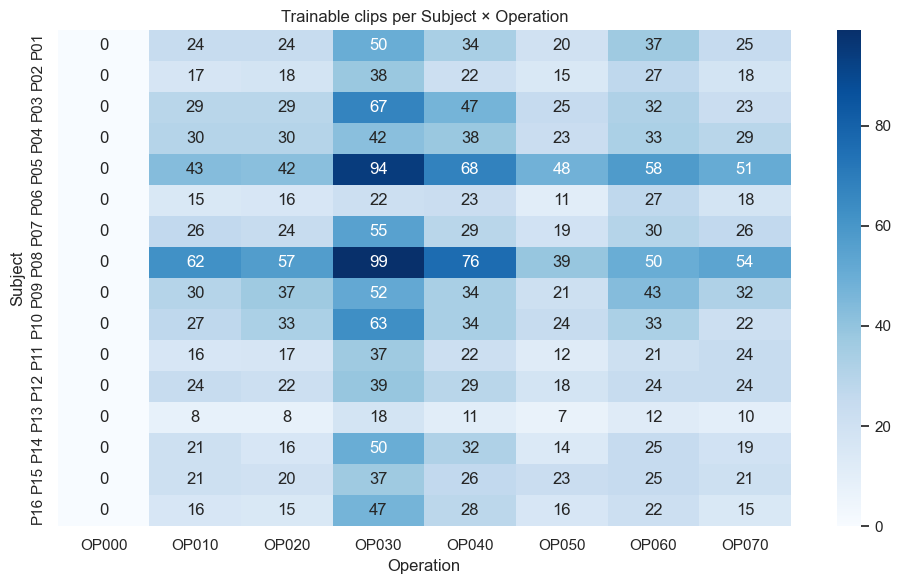

In [8]:
pivot = pd.crosstab(df["Subject"], df["Operation"], values=df["is_trainable"], aggfunc="sum").fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Trainable clips per Subject × Operation")
plt.tight_layout()
fig.savefig(OUT / "06_subject_operation_heatmap.png", dpi=140)
plt.show()

## Next

- **02_Embedding_Extraction.ipynb** — V-JEPA2 on trainable clips  
- **00_Pipeline_Run_All.ipynb** — run full pipeline